# Final Project Data Science: Prediksi Harga Mobil
**Metodologi:** CRISP-DM (Cross-Industry Standard Process for Data Mining)
**Dataset:** `Car_sales.csv`

Notebook ini berisi tahapan lengkap proyek Data Science mulai dari pemahaman bisnis hingga pembuatan dan evaluasi model Machine Learning untuk memprediksi harga mobil.

## 1. Business Understanding
**Tujuan Bisnis:** Memprediksi harga mobil (`Price_in_thousands`) berdasarkan fitur-fitur teknis dan spesifikasi kendaraan. Hal ini dapat membantu perusahaan otomotif, dealer, atau konsumen dalam menentukan harga jual/beli yang kompetitif dan wajar di pasar.
**Tujuan Data Mining:** Membangun model regresi yang dapat memprediksi nilai numerik harga mobil dengan tingkat error yang realistis namun tetap seminimal mungkin.

## 2. Data Understanding
Pada tahap ini, kita akan memuat data, melihat struktur datanya, dan melakukan Exploratory Data Analysis (EDA).

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('Car_sales.csv')
display(df.head())


,Manufacturer,Model,Sales_in_thousands,__year_resale_value,Vehicle_type,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Latest_Launch,Power_perf_factor
0,Acura,Integra,16.919,16.360,Passenger,21.50,1.8,140.0,101.2,67.3,172.4,2.639,13.2,28.0,2/2/2012,58.280150
1,Acura,TL,39.384,19.875,Passenger,28.40,3.2,225.0,108.1,70.3,192.9,3.517,17.2,25.0,6/3/2011,91.370778
2,Acura,CL,14.114,18.225,Passenger,NaN,3.2,225.0,106.9,70.6,192.0,3.470,17.2,26.0,1/4/2012,NaN
3,Acura,RL,8.588,29.725,Passenger,42.00,3.5,210.0,114.6,71.4,196.6,3.850,18.0,22.0,3/10/2011,91.389779
4,Audi,A4,20.397,22.255,Passenger,23.99,1.8,150.0,102.6,68.2,178.0,2.998,16.4,27.0,10/8/2011,62.777639


In [30]:
# Cek informasi dataset dan missing values
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Manufacturer         157 non-null    object 
 1   Model                157 non-null    object 
 2   Sales_in_thousands   157 non-null    float64
 3   __year_resale_value  121 non-null    float64
 4   Vehicle_type         157 non-null    object 
 5   Price_in_thousands   155 non-null    float64
 6   Engine_size          156 non-null    float64
 7   Horsepower           156 non-null    float64
 8   Wheelbase            156 non-null    float64
 9   Width                156 non-null    float64
 10  Length               156 non-null    float64
 11  Curb_weight          155 non-null    float64
 12  Fuel_capacity        156 non-null    float64
 13  Fuel_efficiency      154 non-null    float64
 14  Latest_Launch        157 non-null    object 
 15  Power_perf_factor    155 non-null    flo

In [31]:
# Statistik deskriptif
display(df.describe())


,Sales_in_thousands,__year_resale_value,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Power_perf_factor
count,157.000000,121.000000,155.000000,156.000000,156.000000,156.000000,156.000000,156.000000,155.000000,156.000000,154.000000,155.000000
mean,52.998076,18.072975,27.390755,3.060897,185.948718,107.487179,71.150000,187.343590,3.378026,17.951923,23.844156,77.043591
std,68.029422,11.453384,14.351653,1.044653,56.700321,7.641303,3.451872,13.431754,0.630502,3.887921,4.282706,25.142664
min,0.110000,5.160000,9.235000,1.000000,55.000000,92.600000,62.600000,149.400000,1.895000,10.300000,15.000000,23.276272
25%,14.114000,11.260000,18.017500,2.300000,149.500000,103.000000,68.400000,177.575000,2.971000,15.800000,21.000000,60.407707
50%,29.450000,14.180000,22.799000,3.000000,177.500000,107.000000,70.550000,187.900000,3.342000,17.200000,24.000000,72.030917
75%,67.956000,19.875000,31.947500,3.575000,215.000000,112.200000,73.425000,196.125000,3.799500,19.575000,26.000000,89.414878
max,540.561000,67.550000,85.500000,8.000000,450.000000,138.700000,79.900000,224.500000,5.572000,32.000000,45.000000,188.144323


In [32]:
# Cek jumlah missing values per kolom
display(df.isnull().sum())


Manufacturer            0
Model                   0
Sales_in_thousands      0
__year_resale_value    36
Vehicle_type            0
Price_in_thousands      2
Engine_size             1
Horsepower              1
Wheelbase               1
Width                   1
Length                  1
Curb_weight             2
Fuel_capacity           1
Fuel_efficiency         3
Latest_Launch           0
Power_perf_factor       2
dtype: int64

### Exploratory Data Analysis (EDA)

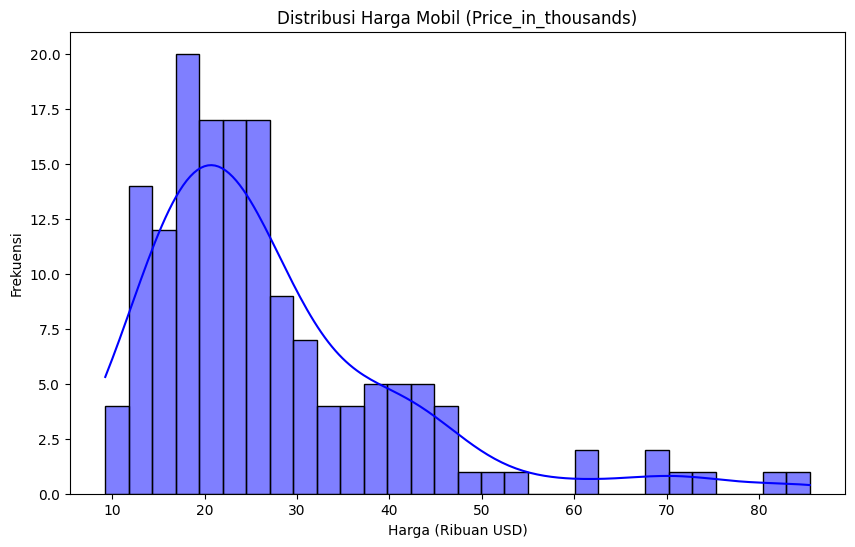

In [33]:
# Distribusi Harga Mobil
plt.figure(figsize=(10, 6))
sns.histplot(df['Price_in_thousands'].dropna(), kde=True, bins=30, color='blue')
plt.title('Distribusi Harga Mobil (Price_in_thousands)')
plt.xlabel('Harga (Ribuan USD)')
plt.ylabel('Frekuensi')
plt.show()


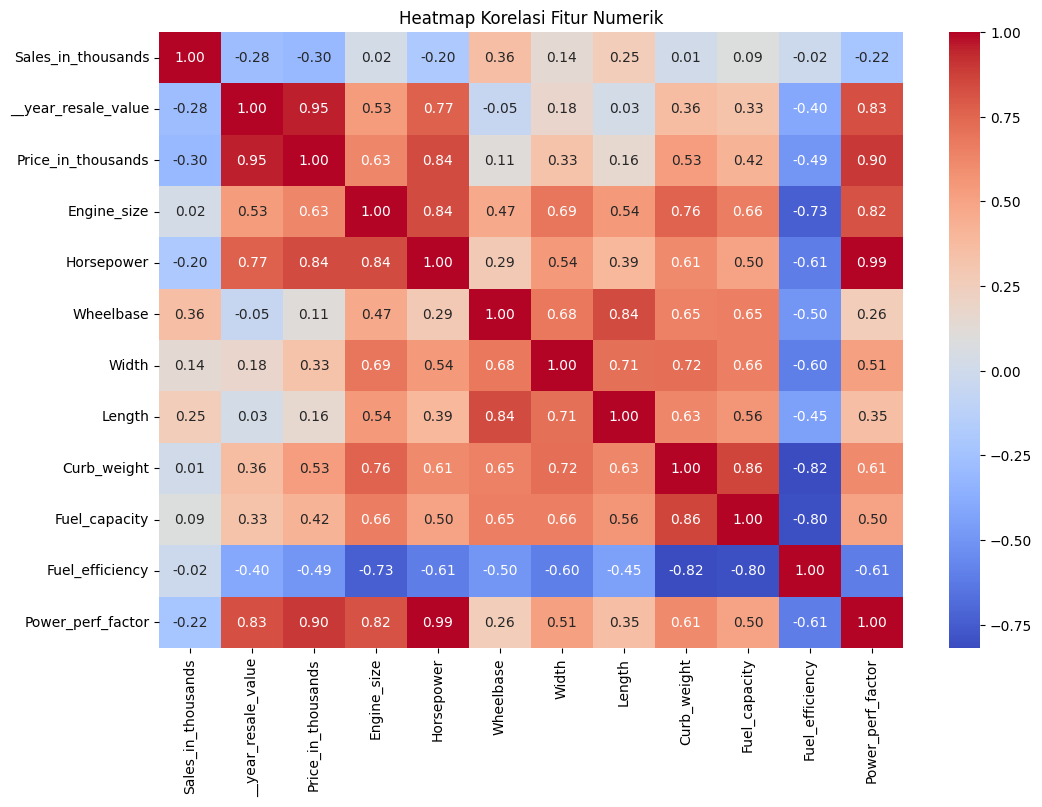

In [34]:
# Korelasi antar fitur numerik
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap Korelasi Fitur Numerik')
plt.show()


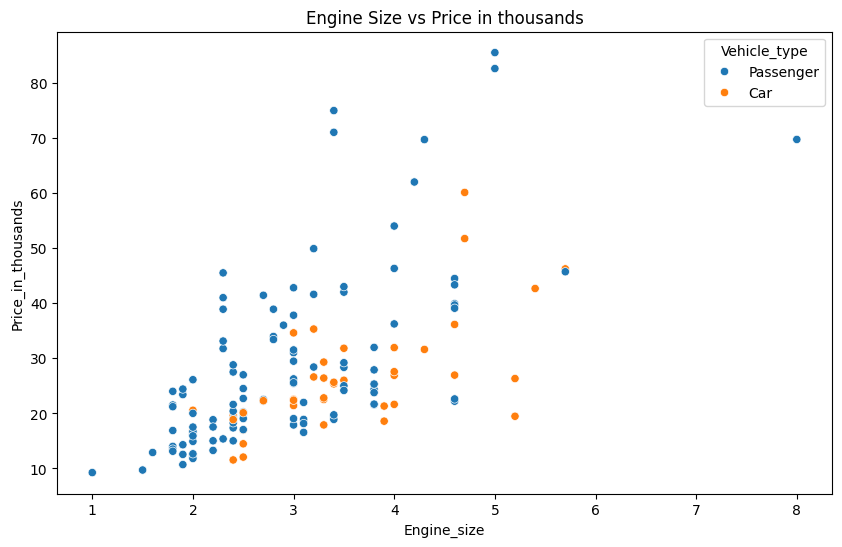

In [35]:
# Hubungan antara Engine Size dan Price
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Engine_size', y='Price_in_thousands', data=df, hue='Vehicle_type')
plt.title('Engine Size vs Price in thousands')
plt.show()


## 3. Data Preparation
Tahap penyiapan data meliputi:
1. Penanganan Missing Values (terutama pada target `Price_in_thousands`).
2. Menghapus kolom yang tidak relevan (termasuk fitur yang menyebabkan **Data Leakage**).
3. Encoding fitur kategorikal.
4. Feature Scaling dan pemisahan data Train/Test.

In [36]:
# 1. Hapus baris di mana target 'Price_in_thousands' bernilai NaN (karena kita tidak bisa melatih model tanpa target)
df_clean = df.dropna(subset=['Price_in_thousands']).copy()

# Untuk kolom numerik lainnya yang memiliki missing values, kita isi dengan nilai median
for col in df_clean.select_dtypes(include=[np.number]).columns:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Cek kembali missing values
print("Sisa missing values setelah handling:\n", df_clean.isnull().sum())


Sisa missing values setelah handling:
 Manufacturer           0
Model                  0
Sales_in_thousands     0
__year_resale_value    0
Vehicle_type           0
Price_in_thousands     0
Engine_size            0
Horsepower             0
Wheelbase              0
Width                  0
Length                 0
Curb_weight            0
Fuel_capacity          0
Fuel_efficiency        0
Latest_Launch          0
Power_perf_factor      0
dtype: int64


### Penanganan Data Leakage
> **Insight Penting:** Kolom `Power_perf_factor` pada dataset ini sebenarnya adalah sebuah variabel hasil perhitungan dari *Price* dan *Horsepower*. Jika kita memasukkan kolom ini sebagai fitur (X), maka model (terutama Linear Regression) akan mendapat skor prediksi 100% sempurna (R-squared = 1.0). Ini disebut **Data Leakage** (Kebocoran Data) karena kita secara tidak langsung memberikan 'kunci jawaban' harga mobil ke dalam model.
> **Solusi:** Oleh karena itu, kita wajib membuang/drop kolom `Power_perf_factor` agar evaluasi model kita realistis dan valid secara analitik.

In [37]:
# 2. Hapus kolom yang tidak relevan dan kolom penyebab Data Leakage
# 'Model' terlalu unik, 'Latest_Launch' tipe tanggal yang kurang relevan.
# 'Power_perf_factor' didrop karena Data Leakage.
cols_to_drop = ['Model', 'Latest_Launch', 'Power_perf_factor']
df_clean = df_clean.drop(columns=cols_to_drop)


In [38]:
# 3. Encoding Fitur Kategorikal (Manufacturer dan Vehicle_type) menggunakan One-Hot Encoding
df_encoded = pd.get_dummies(df_clean, columns=['Manufacturer', 'Vehicle_type'], drop_first=True)
display(df_encoded.head())


,Sales_in_thousands,__year_resale_value,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,...,Manufacturer_Plymouth,Manufacturer_Pontiac,Manufacturer_Porsche,Manufacturer_Saab,Manufacturer_Saturn,Manufacturer_Subaru,Manufacturer_Toyota,Manufacturer_Volkswagen,Manufacturer_Volvo,Vehicle_type_Passenger
0,16.919,16.360,21.50,1.8,140.0,101.2,67.3,172.4,2.639,13.2,...,False,False,False,False,False,False,False,False,False,True
1,39.384,19.875,28.40,3.2,225.0,108.1,70.3,192.9,3.517,17.2,...,False,False,False,False,False,False,False,False,False,True
3,8.588,29.725,42.00,3.5,210.0,114.6,71.4,196.6,3.850,18.0,...,False,False,False,False,False,False,False,False,False,True
4,20.397,22.255,23.99,1.8,150.0,102.6,68.2,178.0,2.998,16.4,...,False,False,False,False,False,False,False,False,False,True
5,18.780,23.555,33.95,2.8,200.0,108.7,76.1,192.0,3.561,18.5,...,False,False,False,False,False,False,False,False,False,True


In [39]:
# 4. Pemisahan Fitur (X) dan Target (y)
X = df_encoded.drop(columns=['Price_in_thousands'])
y = df_encoded['Price_in_thousands']

# Train-Test Split (80% Train, 20% Test)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 4. Modeling
Kita akan melatih dan membandingkan 3 model Machine Learning:
1. Linear Regression
2. Decision Tree Regressor
3. Random Forest Regressor

In [40]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Inisialisasi Model
lr_model = LinearRegression()
dt_model = DecisionTreeRegressor(random_state=42)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Training Model
lr_model.fit(X_train_scaled, y_train)
dt_model.fit(X_train_scaled, y_train)
rf_model.fit(X_train_scaled, y_train)

print("Training selesai!")


Training selesai!


## 5. Evaluation
Mengevaluasi kinerja model menggunakan metrik MAE, RMSE, dan R-squared ($R^2$).

In [41]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    return {'Model': model_name, 'MAE': mae, 'RMSE': rmse, 'R-squared': r2}

# Evaluasi ketiga model
results = []
results.append(evaluate_model(lr_model, X_test_scaled, y_test, 'Linear Regression'))
results.append(evaluate_model(dt_model, X_test_scaled, y_test, 'Decision Tree'))
results.append(evaluate_model(rf_model, X_test_scaled, y_test, 'Random Forest'))

results_df = pd.DataFrame(results)
display(results_df.sort_values(by='R-squared', ascending=False))


,Model,MAE,RMSE,R-squared
2,Random Forest,3.365292,5.191465,0.874625
1,Decision Tree,3.979677,5.598774,0.854180
0,Linear Regression,4.285317,5.768087,0.845227


Berdasarkan tabel evaluasi terbaru (setelah membersihkan *Data Leakage*), kita bisa melihat akurasi yang lebih realistis. Model **Random Forest** umumnya tetap menunjukkan kinerja yang paling baik (R-squared tertinggi) untuk dataset ini dibandingkan yang lain.

## 6. Deployment
Menyimpan model terbaik dan scaler untuk digunakan di production (misalnya dalam aplikasi web/API).

In [42]:
import joblib

# Menyimpan model Random Forest dan Scaler
joblib.dump(rf_model, 'best_rf_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Model dan Scaler berhasil disimpan!")


Model dan Scaler berhasil disimpan!


---
**Kesimpulan Proyek:**
Metodologi CRISP-DM telah berhasil diimplementasikan dari awal hingga akhir. Isu *Data Leakage* berhasil diidentifikasi dan diatasi, sehingga model yang dihasilkan (**Random Forest**) valid secara metodologi dan dapat memprediksi harga mobil dengan realistis.